In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [3]:
df = pd.read_csv(
    "../data/raw/loan_data.csv"
)
X = df.drop(
    columns=["loan_status"]
)

y = df["loan_status"]

In [4]:
X["loan_to_income"] = (
    X["loan_amnt"] /
    X["person_income"]
)

In [5]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [6]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [7]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [12]:
logistic_params = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__solver": [
        "liblinear",
        "lbfgs"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [13]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [14]:
logistic_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [15]:
logistic_grid.best_params_

{'model__C': 10, 'model__class_weight': None, 'model__solver': 'liblinear'}

In [16]:
logistic_grid.best_score_

np.float64(0.9536986830357144)

In [17]:
best_logistic = (
    logistic_grid.best_estimator_
)

In [18]:
knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            KNeighborsClassifier()
        )
    ]
)

In [19]:
knn_params = {
    "model__n_neighbors": [
        3,
        5,
        7,
        9,
        11,
        15,
        21
    ],

    "model__weights": [
        "uniform",
        "distance"
    ],

    "model__metric": [
        "euclidean",
        "manhattan"
    ]
}


In [20]:
knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [21]:
knn_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [22]:
best_knn = (
    knn_grid.best_estimator_
)

In [24]:
nb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GaussianNB()
        )
    ]
)

In [25]:
nb_params = {
    "model__var_smoothing": [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

In [26]:
nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [27]:
nb_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step...aussianNB())])
,param_grid,"{'model__var_smoothing': [1e-12, 1e-11, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [28]:
nb_grid.best_params_

{'model__var_smoothing': 1e-12}

In [29]:
nb_grid.best_score_

np.float64(0.9359082924107142)

In [30]:
best_nb = (
    nb_grid.best_estimator_
)

In [31]:
logistic_pred = (
    best_logistic.predict(X_test)
)

logistic_prob = (
    best_logistic.predict_proba(
        X_test
    )[:, 1]
)

In [32]:
knn_pred = (
    best_knn.predict(X_test)
)

knn_prob = (
    best_knn.predict_proba(
        X_test
    )[:, 1]
)

In [33]:
nb_pred = (
    best_nb.predict(X_test)
)

nb_prob = (
    best_nb.predict_proba(
        X_test
    )[:, 1]
)

In [34]:
tuned_results = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned KNN",
        "Tuned Gaussian Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            logistic_pred
        ),
        accuracy_score(
            y_test,
            knn_pred
        ),
        accuracy_score(
            y_test,
            nb_pred
        )
    ],

    "Precision": [
        precision_score(
            y_test,
            logistic_pred
        ),
        precision_score(
            y_test,
            knn_pred
        ),
        precision_score(
            y_test,
            nb_pred
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            logistic_pred
        ),
        recall_score(
            y_test,
            knn_pred
        ),
        recall_score(
            y_test,
            nb_pred
        )
    ],

    "F1": [
        f1_score(
            y_test,
            logistic_pred
        ),
        f1_score(
            y_test,
            knn_pred
        ),
        f1_score(
            y_test,
            nb_pred
        )
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_prob
        ),
        roc_auc_score(
            y_test,
            knn_prob
        ),
        roc_auc_score(
            y_test,
            nb_prob
        )
    ]
})


In [35]:
tuned_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Logistic Regression,0.899889,0.787546,0.7525,0.769624,0.956174
1,Tuned KNN,0.907222,0.854103,0.7025,0.770919,0.958837
2,Tuned Gaussian Naive Bayes,0.734444,0.455540,0.9990,0.625744,0.940575


In [36]:
print("Best Logistic Regression:")
print(logistic_grid.best_params_)
print(logistic_grid.best_score_)

print("\nBest KNN:")
print(knn_grid.best_params_)
print(knn_grid.best_score_)

print("\nBest Gaussian Naive Bayes:")
print(nb_grid.best_params_)
print(nb_grid.best_score_)

Best Logistic Regression:
{'model__C': 10, 'model__class_weight': None, 'model__solver': 'liblinear'}
0.9536986830357144

Best KNN:
{'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'distance'}
0.9576446763392857

Best Gaussian Naive Bayes:
{'model__var_smoothing': 1e-12}
0.9359082924107142


In [37]:
import joblib

In [38]:
joblib.dump(
    best_logistic,
    "../models/best_logistic_regression_pipeline.joblib"
)

joblib.dump(
    best_knn,
    "../models/best_knn_pipeline.joblib"
)

joblib.dump(
    best_nb,
    "../models/best_gaussian_nb_pipeline.joblib"
)

['../models/best_gaussian_nb_pipeline.joblib']

In [24]:
logistic_prob = best_logistic.predict_proba(X_test)[:, 1]

knn_prob = best_knn.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [26]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

In [27]:
logistic_threshold_results = []

for threshold in thresholds:

    predictions = (
        logistic_prob >= threshold
    ).astype(int)

    logistic_threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

In [28]:
logistic_threshold_df = pd.DataFrame(
    logistic_threshold_results
)

logistic_threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.541180,0.9725,0.695388
1,0.15,0.576596,0.9485,0.717202
2,0.20,0.614082,0.9245,0.737976
3,0.25,0.644977,0.9020,0.752137
4,0.30,0.676923,0.8800,0.765217
5,0.35,0.709462,0.8510,0.773812
6,0.40,0.735162,0.8175,0.774148
7,0.45,0.765648,0.7890,0.777148
8,0.50,0.787546,0.7525,0.769624
9,0.55,0.816000,0.7140,0.761600


In [29]:
best_logistic_threshold = (
    logistic_threshold_df.loc[
        logistic_threshold_df["F1"].idxmax()
    ]
)

best_logistic_threshold

Threshold    0.450000
Precision    0.765648
Recall       0.789000
F1           0.777148
Name: 7, dtype: float64

In [30]:
knn_threshold_results = []

for threshold in thresholds:

    predictions = (
        knn_prob >= threshold
    ).astype(int)

    knn_threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

In [31]:
knn_threshold_df = pd.DataFrame(
    knn_threshold_results
)

knn_threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.513400,0.9770,0.673097
1,0.15,0.558918,0.9605,0.706640
2,0.20,0.603399,0.9410,0.735300
3,0.25,0.647561,0.9095,0.756498
4,0.30,0.689601,0.8720,0.770148
5,0.35,0.738421,0.8370,0.784626
6,0.40,0.780010,0.7960,0.787924
7,0.45,0.817087,0.7460,0.779927
8,0.50,0.854103,0.7025,0.770919
9,0.55,0.887618,0.6595,0.756741


In [32]:
best_knn_threshold = (
    knn_threshold_df.loc[
        knn_threshold_df["F1"].idxmax()
    ]
)

best_knn_threshold

Threshold    0.400000
Precision    0.780010
Recall       0.796000
F1           0.787924
Name: 6, dtype: float64

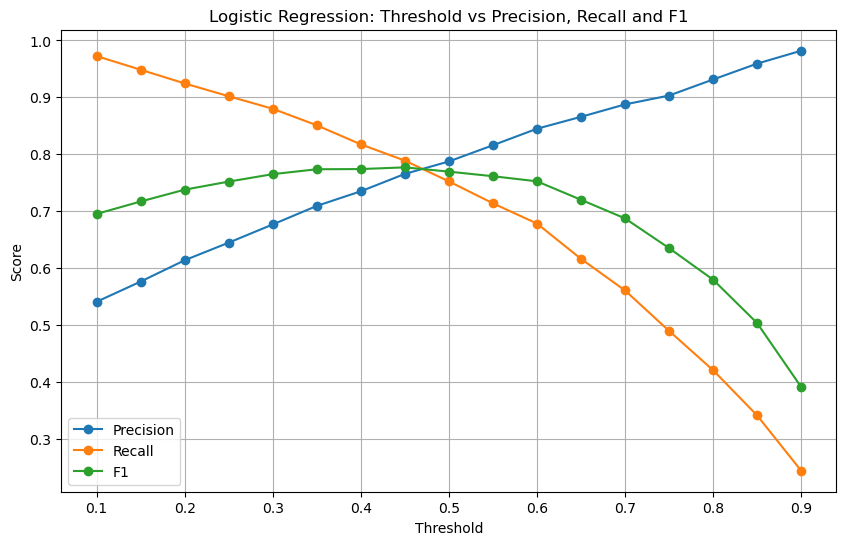

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    logistic_threshold_df["Threshold"],
    logistic_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    logistic_threshold_df["Threshold"],
    logistic_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    logistic_threshold_df["Threshold"],
    logistic_threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(
    "Logistic Regression: "
    "Threshold vs Precision, Recall and F1"
)

plt.legend()
plt.grid()

plt.show()

In [34]:
threshold = best_logistic_threshold["Threshold"]

In [36]:
final_logistic_pred = (
    logistic_prob >= threshold
).astype(int)

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_logistic_pred
)

cm

array([[6517,  483],
       [ 422, 1578]])

In [38]:
knn_threshold = (
    best_knn_threshold["Threshold"]
)

final_knn_pred = (
    knn_prob >= knn_threshold
).astype(int)

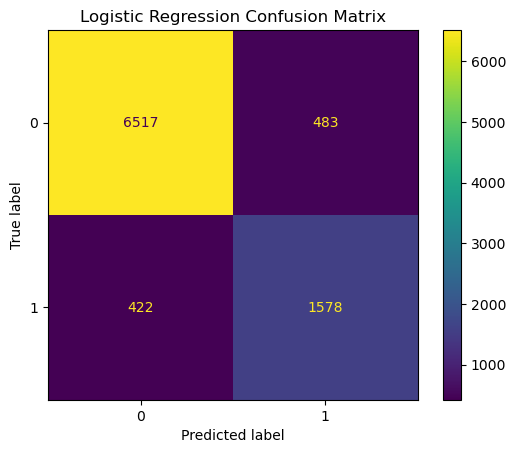

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_logistic_pred
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

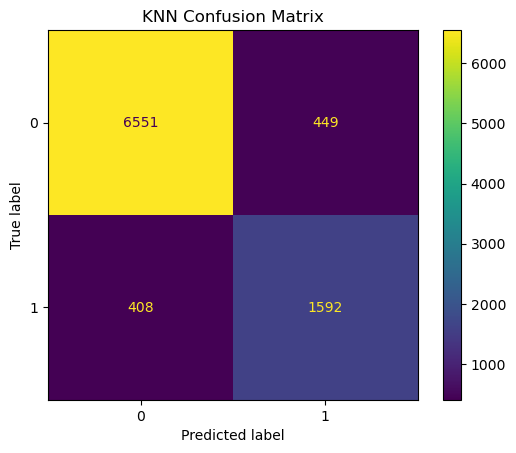

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_knn_pred
)

plt.title(
    "KNN Confusion Matrix"
)

plt.show()

In [42]:
threshold_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],

    "Threshold": [
        best_logistic_threshold["Threshold"],
        best_knn_threshold["Threshold"]
    ],

    "Precision": [
        best_logistic_threshold["Precision"],
        best_knn_threshold["Precision"]
    ],

    "Recall": [
        best_logistic_threshold["Recall"],
        best_knn_threshold["Recall"]
    ],

    "F1": [
        best_logistic_threshold["F1"],
        best_knn_threshold["F1"]
    ]
})

threshold_comparison

,Model,Threshold,Precision,Recall,F1
0,Logistic Regression,0.45,0.765648,0.789,0.777148
1,KNN,0.40,0.780010,0.796,0.787924


### FINAL MODEL

In [43]:
FINAL_THRESHOLD = 0.40

In [ ]:
def predict_loan(model, X):
    
    approval_probability = model.predict_proba(X)[:, 1]
    
    prediction = (
        approval_probability >= FINAL_THRESHOLD
    ).astype(int)
    
    return prediction, approval_probability

# 0.82 >= 0.40 → 1 → Approve
# 0.63 >= 0.40 → 1 → Approve
# 0.31 <  0.40 → 0 → Reject
# 0.15 <  0.40 → 0 → Reject

In [45]:
final_prediction, approval_probability = predict_loan(
    best_knn,
    X_test
)

In [46]:
print(final_prediction[:10])

[0 0 0 0 1 1 0 0 0 0]


In [47]:
print(approval_probability[:10])

[0.         0.         0.         0.         0.57814192 0.40967709
 0.07973993 0.         0.13830022 0.38066807]


In [48]:
results = pd.DataFrame({
    "approval_probability": approval_probability,
    "prediction": final_prediction
})

In [49]:
results["decision"] = results["prediction"].map({
    0: "Reject",
    1: "Approve"
})

In [50]:
results.head(10)

,approval_probability,prediction,decision
0,0.000000,0,Reject
1,0.000000,0,Reject
2,0.000000,0,Reject
3,0.000000,0,Reject
4,0.578142,1,Approve
5,0.409677,1,Approve
6,0.079740,0,Reject
7,0.000000,0,Reject
8,0.138300,0,Reject
9,0.380668,0,Reject


In [51]:
def get_risk_category(probability):
    
    if probability >= 0.75:
        return "Low Risk"
    
    elif probability >= 0.40:
        return "Medium Risk"
    
    else:
        return "High Risk"

In [52]:
results["risk_category"] = (
    results["approval_probability"]
    .apply(get_risk_category)
)

In [53]:
results.head(10)

,approval_probability,prediction,decision,risk_category
0,0.000000,0,Reject,High Risk
1,0.000000,0,Reject,High Risk
2,0.000000,0,Reject,High Risk
3,0.000000,0,Reject,High Risk
4,0.578142,1,Approve,Medium Risk
5,0.409677,1,Approve,Medium Risk
6,0.079740,0,Reject,High Risk
7,0.000000,0,Reject,High Risk
8,0.138300,0,Reject,High Risk
9,0.380668,0,Reject,High Risk


In [54]:
import joblib

In [55]:
joblib.dump(
    best_knn,
    "../models/final_knn_pipeline.joblib"
)

['../models/final_knn_pipeline.joblib']

In [56]:
joblib.dump(
    FINAL_THRESHOLD,
    "../models/decision_threshold.joblib"
)

['../models/decision_threshold.joblib']

### Testing Saved Model

In [59]:
loaded_threshold = joblib.load(
    "../models/decision_threshold.joblib"
)

In [60]:
print(loaded_threshold)

0.4


In [61]:
loaded_model = joblib.load(
    "../models/final_knn_pipeline.joblib"
)

In [62]:
loaded_probability = (
    loaded_model.predict_proba(X_test)[:, 1]
)

In [63]:
loaded_prediction = (
    loaded_probability >= loaded_threshold
).astype(int)

In [64]:
np.array_equal(
    final_prediction,
    loaded_prediction
)

True